In [1]:
# Ignorar Avisos
import warnings
warnings.filterwarnings('ignore')

In [34]:
import pandas as pd
import numpy as np
import glob
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from statsmodels.stats.proportion import proportions_ztest

In [3]:
# Tirar truncamento de colunas
pd.set_option('display.max_columns', None)

In [5]:
arquivo = glob.glob(r'C:\Estudos\Hackathon POD\Analise\tabela_analise.parquet\*.parquet')
dados = pd.read_parquet(arquivo)

In [6]:
dados.head()

,NUM_CPF,ID_UNICO,IDADE,SAFRA,PROD,FLAG_INSTALACAO,flag_mig2,SCORE_01,SCORE_02,FPD,STATUSRF,NUM_STATUSRF,FUNC_PUBL,CARGO_FUNC_PUBL,SALARIO_FUNC_PUBL,EMPR_DIRETOR,VALOR_EMPR_DIRETOR,BOLSA_FAMILIA,UF_BOLSA_FAMILIA,BENEFICIO_BOLSA_FAMILIA,APOSENTADO,NUMERO_APOSENTADO,AUXILLIO_EMERGENCIAL,MESES_AUXILIO_EMERGENCIAL,FUNC_PRIVADO,STATUS_FUNC_PRIVADO,DATA_FUNC_PRIVADO,CONSOLIDADO,CEP_3_digitos,POSSUI_POS
0,77777XZ77ZU,77777XZ77ZU202411,63,202411,CMV,1,Aquisição,560,584,0,REGULAR,0,0,NAO_APLICAVEL,-1.0,0,-1.0,0,NAO_APLICAVEL,0.0,0,-1,0,0,1,ADMITIDO,2016-11-04,FUNC_PRIVADO,273,0
1,777789Y8TXT,777789Y8TXT202503,45,202503,CMV,1,PRE,643,797,0,REGULAR,0,0,NAO_APLICAVEL,-1.0,0,-1.0,0,NAO_APLICAVEL,0.0,0,-1,0,0,1,ADMITIDO,2006-10-18,FUNC_PRIVADO,407,0
2,77778X7ZWTW,77778X7ZWTW202411,46,202411,CMV,1,PRE,595,588,0,REGULAR,0,0,NAO_APLICAVEL,-1.0,1,1.0,0,NAO_APLICAVEL,0.0,0,-1,1,9,0,NAO_APLICAVEL,9999-01-01,AUX_EMRG EMPR/DIRETOR,644,1
3,7777NW8Z7N8,7777NW8Z7N8202412,70,202412,CMV,0,SEM_MIGRACAO,551,496,None,REGULAR,0,0,NAO_APLICAVEL,-1.0,0,-1.0,0,NAO_APLICAVEL,0.0,1,88,1,9,0,NAO_APLICAVEL,9999-01-01,APOSENTADO AUX_EMRG,217,0
4,7777NW8Z7N8,7777NW8Z7N8202411,70,202411,CMV,0,SEM_MIGRACAO,551,491,None,REGULAR,0,0,NAO_APLICAVEL,-1.0,0,-1.0,0,NAO_APLICAVEL,0.0,1,88,1,9,0,NAO_APLICAVEL,9999-01-01,APOSENTADO AUX_EMRG,217,0


In [7]:
# Separando dados que adquiriram
df = dados[dados['FPD'].notnull()]
df['FPD'] = df['FPD'].astype(int)

In [8]:
df.head()

,NUM_CPF,ID_UNICO,IDADE,SAFRA,PROD,FLAG_INSTALACAO,flag_mig2,SCORE_01,SCORE_02,FPD,STATUSRF,NUM_STATUSRF,FUNC_PUBL,CARGO_FUNC_PUBL,SALARIO_FUNC_PUBL,EMPR_DIRETOR,VALOR_EMPR_DIRETOR,BOLSA_FAMILIA,UF_BOLSA_FAMILIA,BENEFICIO_BOLSA_FAMILIA,APOSENTADO,NUMERO_APOSENTADO,AUXILLIO_EMERGENCIAL,MESES_AUXILIO_EMERGENCIAL,FUNC_PRIVADO,STATUS_FUNC_PRIVADO,DATA_FUNC_PRIVADO,CONSOLIDADO,CEP_3_digitos,POSSUI_POS
0,77777XZ77ZU,77777XZ77ZU202411,63,202411,CMV,1,Aquisição,560,584,0,REGULAR,0,0,NAO_APLICAVEL,-1.0,0,-1.0,0,NAO_APLICAVEL,0.0,0,-1,0,0,1,ADMITIDO,2016-11-04,FUNC_PRIVADO,273,0
1,777789Y8TXT,777789Y8TXT202503,45,202503,CMV,1,PRE,643,797,0,REGULAR,0,0,NAO_APLICAVEL,-1.0,0,-1.0,0,NAO_APLICAVEL,0.0,0,-1,0,0,1,ADMITIDO,2006-10-18,FUNC_PRIVADO,407,0
2,77778X7ZWTW,77778X7ZWTW202411,46,202411,CMV,1,PRE,595,588,0,REGULAR,0,0,NAO_APLICAVEL,-1.0,1,1.0,0,NAO_APLICAVEL,0.0,0,-1,1,9,0,NAO_APLICAVEL,9999-01-01,AUX_EMRG EMPR/DIRETOR,644,1
7,7777WW8XUTW,7777WW8XUTW202410,53,202410,NET,1,SEM_MIGRACAO,-1,-1,0,REGULAR,0,0,NAO_APLICAVEL,-1.0,0,-1.0,0,NAO_APLICAVEL,0.0,0,-1,0,0,1,ADMITIDO,2009-09-01,FUNC_PRIVADO,570,1
8,7777WW8XUTW,7777WW8XUTW202503,53,202503,CMV,1,PRE,612,689,0,REGULAR,0,0,NAO_APLICAVEL,-1.0,0,-1.0,0,NAO_APLICAVEL,0.0,0,-1,0,0,1,ADMITIDO,2009-09-01,FUNC_PRIVADO,570,1


In [9]:
# Separando dados que não adquiriram
df2 = dados[dados['FPD'].isnull()].drop(columns = ['FPD', 'FLAG_INSTALACAO', 'flag_mig2'])

In [10]:
df2.head()

,NUM_CPF,ID_UNICO,IDADE,SAFRA,PROD,SCORE_01,SCORE_02,STATUSRF,NUM_STATUSRF,FUNC_PUBL,CARGO_FUNC_PUBL,SALARIO_FUNC_PUBL,EMPR_DIRETOR,VALOR_EMPR_DIRETOR,BOLSA_FAMILIA,UF_BOLSA_FAMILIA,BENEFICIO_BOLSA_FAMILIA,APOSENTADO,NUMERO_APOSENTADO,AUXILLIO_EMERGENCIAL,MESES_AUXILIO_EMERGENCIAL,FUNC_PRIVADO,STATUS_FUNC_PRIVADO,DATA_FUNC_PRIVADO,CONSOLIDADO,CEP_3_digitos,POSSUI_POS
3,7777NW8Z7N8,7777NW8Z7N8202412,70,202412,CMV,551,496,REGULAR,0,0,NAO_APLICAVEL,-1.0,0,-1.0,0,NAO_APLICAVEL,0.0,1,88,1,9,0,NAO_APLICAVEL,9999-01-01,APOSENTADO AUX_EMRG,217,0
4,7777NW8Z7N8,7777NW8Z7N8202411,70,202411,CMV,551,491,REGULAR,0,0,NAO_APLICAVEL,-1.0,0,-1.0,0,NAO_APLICAVEL,0.0,1,88,1,9,0,NAO_APLICAVEL,9999-01-01,APOSENTADO AUX_EMRG,217,0
5,7777UX8WZZZ,7777UX8WZZZ202410,47,202410,CMV,600,640,REGULAR,0,0,NAO_APLICAVEL,-1.0,0,-1.0,1,RS,338.0,0,-1,1,9,0,NAO_APLICAVEL,9999-01-01,AUX_EMRG BOLSA_FAMILIA,917,0
6,7777UZ78ZTW,7777UZ78ZTW202410,79,202410,CMV,623,618,REGULAR,0,0,NAO_APLICAVEL,-1.0,0,-1.0,0,NAO_APLICAVEL,0.0,1,88,0,0,0,NAO_APLICAVEL,9999-01-01,APOSENTADO,917,0
9,7777WYN87YZ,7777WYN87YZ202501,60,202501,CMV,589,604,REGULAR,0,0,NAO_APLICAVEL,-1.0,0,-1.0,0,NAO_APLICAVEL,0.0,0,-1,0,0,1,ADMITIDO,2016-06-20,FUNC_PRIVADO,247,0


## Overview

In [11]:
print(30*'=')
print('DIMENSÕES DATASET COMPLETO')
print(30*'=')
print("Linhas:", dados.shape[0])
print("Colunas:", dados.shape[1])

DIMENSÕES DATASET COMPLETO
Linhas: 3900378
Colunas: 30


In [12]:
print(40*'=')
print("QTD DE REGISTROS X QTD DE CPF's ÚNICOS")
print(40*'=')

registros = dados['ID_UNICO'].nunique()
cpfs = dados['NUM_CPF'].nunique()

print(f'Numero de registros: {registros}')
print(f"Numero de CPF's: {cpfs}")
print(f'Diferença: {registros - cpfs}')

QTD DE REGISTROS X QTD DE CPF's ÚNICOS
Numero de registros: 3900378
Numero de CPF's: 3590459
Diferença: 309919


In [29]:
print(40*'=')
print('DIMENSÕES DATASET QUE ADIQUIRIRAM')
print(40*'=')
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])

DIMENSÕES DATASET QUE ADIQUIRIRAM
Linhas: 2696621
Colunas: 30


In [30]:
print(40*'=')
print('DIMENSÕES DATASET QUE NÃO ADIQUIRIRAM')
print(40*'=')
print("Linhas:", df2.shape[0])
print("Colunas:", df2.shape[1])

DIMENSÕES DATASET QUE NÃO ADIQUIRIRAM
Linhas: 1203757
Colunas: 27


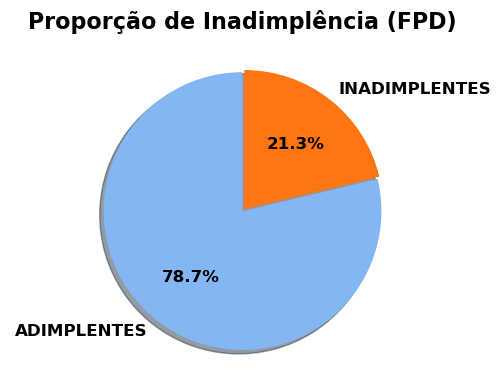

In [39]:
fpd_counts = df['FPD'].value_counts().sort_index()

labels = ['ADIMPLENTES', 'INADIMPLENTES']
cores = ['#84b6f4', '#ff7514'] 

plt.figure(figsize=(6, 4))
plt.pie(
    fpd_counts, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=90,
    explode = (0, 0.02),
    colors=cores, 
    textprops={'fontsize': 12, 'weight': 'bold'},
    shadow = True
)

plt.title('Proporção de Inadimplência (FPD)', fontsize=16, pad=20, fontweight = 'bold')
plt.axis('equal')  
plt.savefig('Inadimplencia', dpi=300)
plt.show()

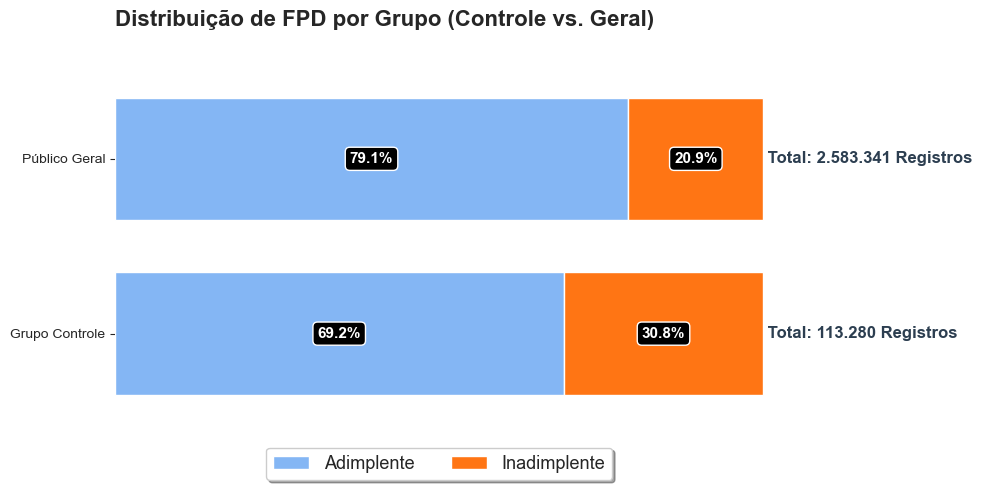

In [98]:
df['GRUPO_ANALISE'] = df['NUM_CPF'].str[5:7].apply(
    lambda x: 'Grupo Controle' if x in ['ZZ', 'ZX'] else 'Público Geral'
)

plot_data = pd.crosstab(df['GRUPO_ANALISE'], df['FPD'], normalize='index') * 100
counts = df['GRUPO_ANALISE'].value_counts()

ax = plot_data.plot(kind='barh', stacked=True, figsize=(10, 5), 
                    color=['#84b6f4', '#ff7514'], width=0.7)

plt.title('Distribuição de FPD por Grupo (Controle vs. Geral)',fontsize=16, pad=20, loc = 'left', fontweight='bold')
plt.xlabel('Porcentagem (%)', fontsize=12)
plt.ylabel('')
plt.legend(['Adimplente', 'Inadimplente'], loc='upper center', bbox_to_anchor=(0.4, 0.0), ncol=2, shadow = True, fontsize = 13)
ax.get_xaxis().set_visible(False) 

for i, (index, row) in enumerate(plot_data.iterrows()):
    ax.annotate(f'{row[0]:.1f}%', 
                (row[0] / 2, i), 
                ha='center', va='center', color='white', fontweight='bold', fontsize=11,
               bbox=dict(boxstyle="round", fc="black"))    

    ax.annotate(f'{row[1]:.1f}%', 
                (row[0] + (row[1] / 2), i), 
                ha='center', va='center', color='white', fontweight='bold', fontsize=11,
               bbox=dict(boxstyle="round", fc="black"))    

    total_registros = counts[index]
    ax.annotate(f' Total: {int(total_registros):,} Registros'.replace(',', '.'), 
                (100, i), 
                ha='left', va='center', fontsize=12, fontweight='bold', color='#2c3e50')

plt.xlim(0, 125) 
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('Controle vs Geral', dpi=300)
plt.show()

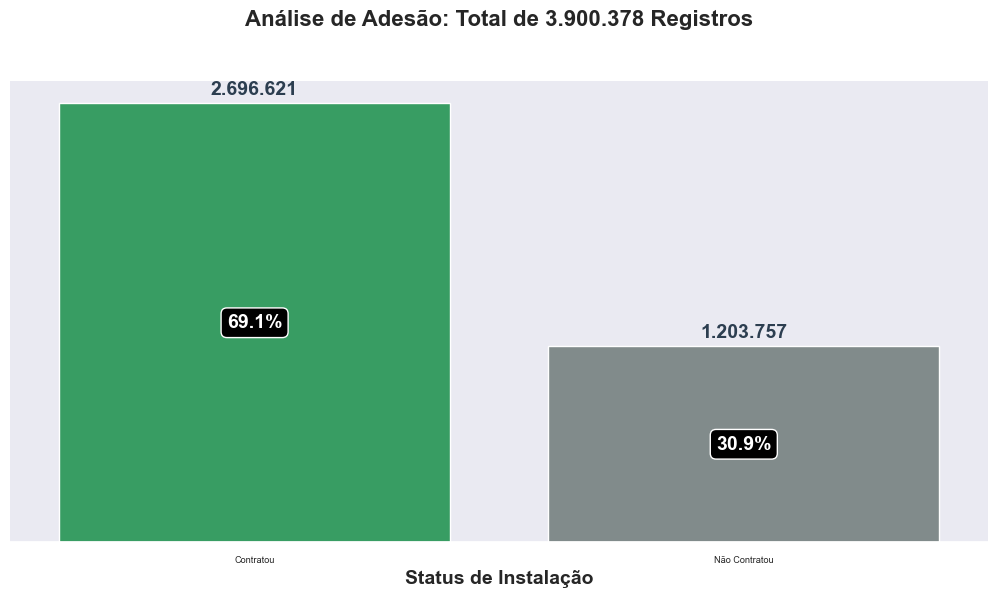

In [48]:
dados['FLAG_INSTALACAO_LABEL'] = dados['FLAG_INSTALACAO'].astype(str).map({
    '1': 'Contratou',
    '0': 'Não Contratou'
})

counts = dados['FLAG_INSTALACAO_LABEL'].value_counts()
total_geral = len(dados)

plt.figure(figsize=(10, 6))
cores = ['#27ae60', '#7f8c8d'] 
ax = sns.barplot(x=counts.index, y=counts.values, palette=cores, )

ax.get_yaxis().set_visible(False) 

for p in ax.patches:
    height = p.get_height()
    percentual = f'{(height/total_geral)*100:.1f}%'    
   
    ax.annotate(f'{int(height):,}'.replace(',', '.'), 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=14, fontweight='bold', color='#2c3e50')    

    ax.annotate(percentual, 
                (p.get_x() + p.get_width() / 2., height / 2), 
                ha='center', va='center', 
                color='white',
                fontsize=14,
                fontweight='bold',
                bbox=dict(boxstyle="round", fc="black"))

plt.title(f'Análise de Adesão: Total de {total_geral:,} Registros'.replace(',', '.'), fontsize=16, pad=40, fontweight='bold')
plt.xlabel('Status de Instalação', fontsize = 14, fontweight = 'bold')

sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.savefig('Adesao', dpi=300)
plt.show()

## Análise de safras

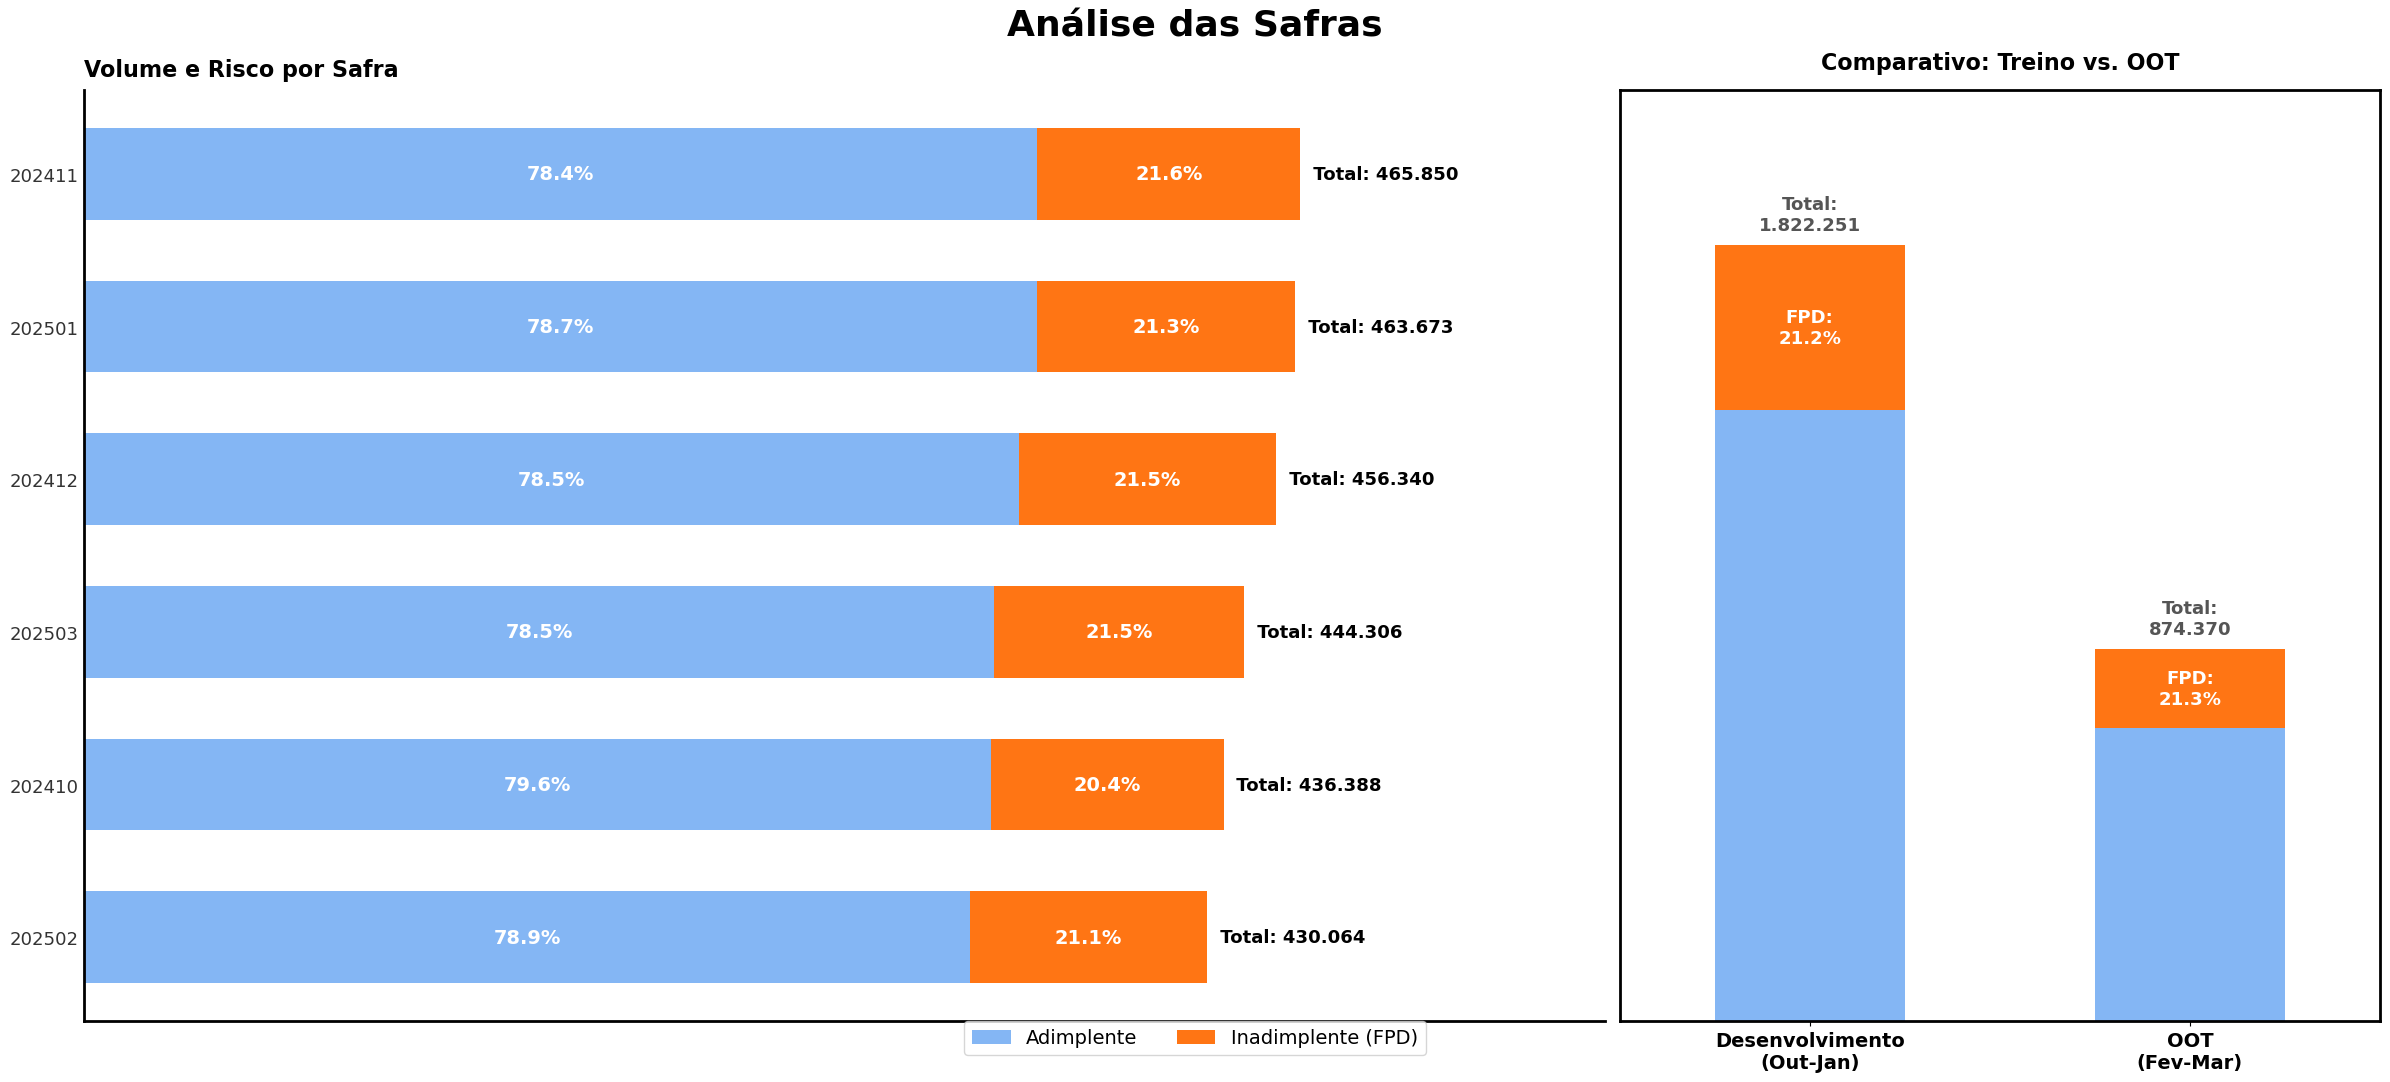

In [126]:
sns.reset_defaults()
df['TIPO_DATA'] = df['SAFRA'].apply(lambda x: 'OOT' if x in ['202502', '202503'] else 'Geral')

def get_stacked_data(df, group_col):
    counts = df.groupby([group_col, 'FPD']).size().unstack(fill_value=0)
    totals = counts.sum(axis=1)
    return counts, totals

counts_s, totals_s = get_stacked_data(df, 'SAFRA')

sorted_idx = totals_s.sort_values(ascending=True).index
counts_s = counts_s.reindex(sorted_idx)
totals_s = totals_s.reindex(sorted_idx)

counts_g, totals_g = get_stacked_data(df, 'TIPO_DATA')
counts_g = counts_g.reindex(['Geral', 'OOT']) 
totals_g = totals_g.reindex(['Geral', 'OOT'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 11), gridspec_kw={'width_ratios': [2, 1]})

fpd_color = '#ff7514'  
non_fpd_color = '#84b6f4' 
bar_width = 0.6 

counts_s.plot(kind='barh', stacked=True, ax=ax1, color=[non_fpd_color, fpd_color], width=bar_width, edgecolor='none')

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(True)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_linewidth(2)
ax1.spines['bottom'].set_linewidth(2)
ax1.spines['left'].set_color('black') 
ax1.spines['bottom'].set_color('black')

ax1.tick_params(axis='y', labelsize=13, labelcolor='#333333', length=0) 
ax1.get_xaxis().set_visible(False) 
ax2.tick_params(axis='y', labelsize=12)
ax1.set_ylabel('') 

max_val_s = totals_s.max()
for i, (idx, row) in enumerate(counts_s.iterrows()):
    total = totals_s[idx]
    pct_fpd = (row[1] / total) * 100
    pct_non = (row[0] / total) * 100

    if row[0] > 0:
        ax1.annotate(f'{pct_non:.1f}%', (row[0]/2, i), 
                     ha='center', va='center', color='white', fontweight='bold', fontsize=14                     
                     )
    if row[1] > 0:
        ax1.annotate(f'{pct_fpd:.1f}%', (row[0] + row[1]/2, i), 
                     ha='center', va='center', color='white', fontweight='bold', fontsize=14
                    )

    ax1.annotate(f' Total: {int(total):,}'.replace(',', '.'), (total, i), 
                 ha='left', va='center', fontweight='bold', fontsize=13, color='black', 
                 xytext=(5, 0), textcoords='offset points') 

ax1.set_title('Volume e Risco por Safra', fontsize=16, pad=10, loc='left',  fontweight='bold')
ax1.set_xlim(0, max_val_s * 1.25) 

counts_g.plot(kind='bar', stacked=True, ax=ax2, color=[non_fpd_color, fpd_color], width=0.5, edgecolor='none')

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

ax2.grid(axis='y', linestyle='--', alpha=0.3)

ax2.get_yaxis().set_visible(False)
ax2.set_xlabel('')
ax2.set_xticklabels(['Desenvolvimento\n(Out-Jan)', 'OOT\n(Fev-Mar)'], rotation=0, fontsize=14, fontweight='bold')

max_val_g = totals_g.max()
for i, (idx, row) in enumerate(counts_g.iterrows()):
    total = totals_g[idx]
    pct_fpd = (row[1] / total) * 100

    ax2.annotate(f'FPD:\n{pct_fpd:.1f}%', (i, row[0] + row[1]/2), 
                 ha='center', va='center', color='white', fontweight='bold', fontsize=13)

    ax2.annotate(f'Total:\n{int(total):,}'.replace(',', '.'), (i, total), 
                 ha='center', va='bottom', fontweight='bold', fontsize=13, color='#555555', 
                 xytext=(0, 8), textcoords='offset points')

ax2.set_title('Comparativo: Treino vs. OOT', fontsize=16, pad=15,  fontweight='bold')
ax2.set_ylim(0, max_val_g * 1.20) 

plt.suptitle('Análise das Safras', fontsize=26, fontweight='bold', y=0.98)

lines, labels = ax1.get_legend_handles_labels()
fig.legend(lines, ['Adimplente', 'Inadimplente (FPD)'], 
           loc='lower center', ncol=2, fontsize=14, 
           bbox_to_anchor=(0.5, 0.02), ) 

ax1.get_legend().remove()
ax2.get_legend().remove()

plt.subplots_adjust(top=0.88, bottom=0.12, wspace=0.10, left=0.05, right=0.95)
plt.tight_layout()
plt.savefig('safras', dpi=300)
plt.show()

## Análise de idades

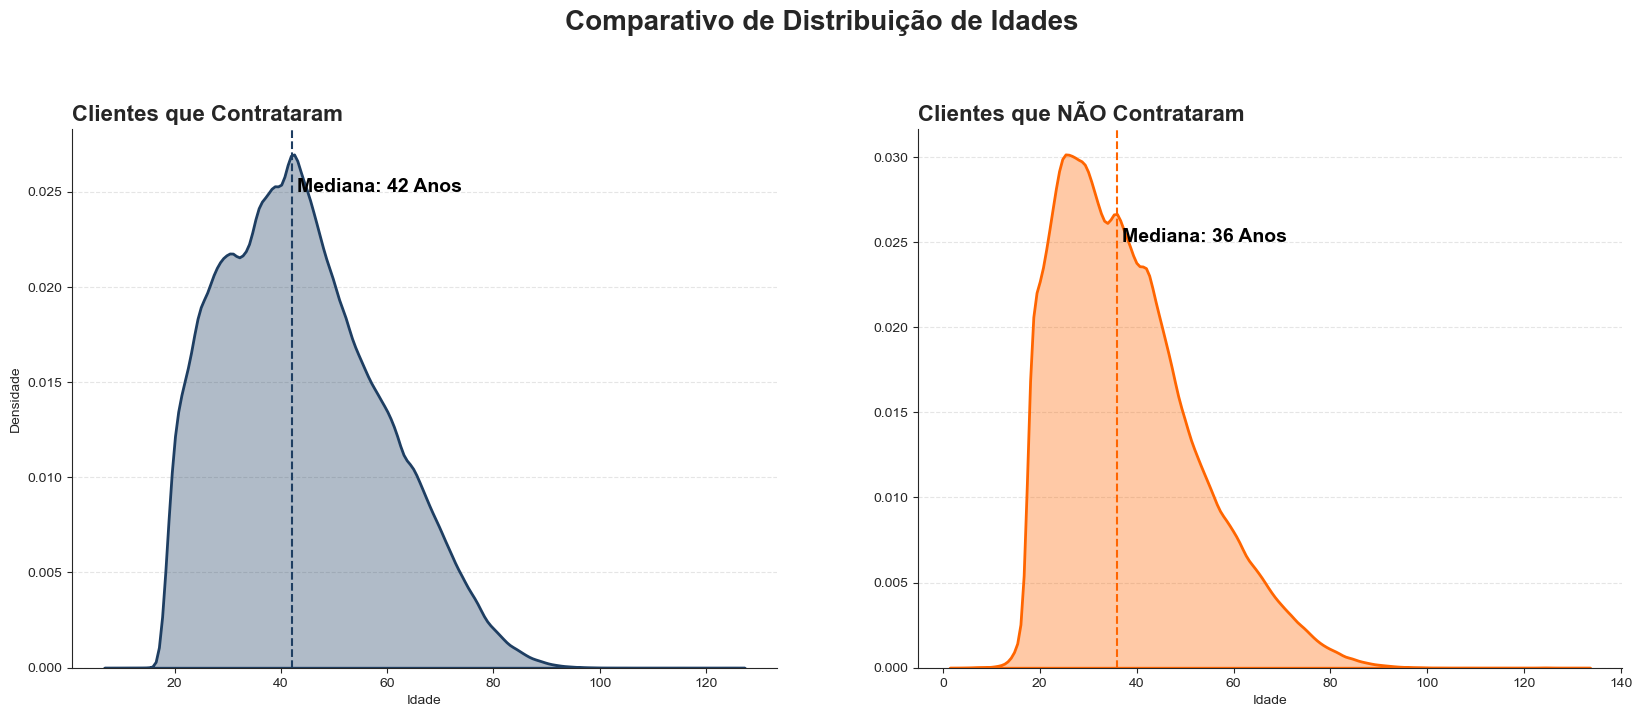

In [72]:
sns.set_style("ticks")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Comparativo de Distribuição de Idades', fontsize=20, fontweight='bold', y=1.05)

sns.kdeplot(
    data=df[df['IDADE'] > 0], 
    x="IDADE",
    fill=True, 
    common_norm=False, 
    alpha=0.35, 
    linewidth=2,
    color='#1E3E62', 
    ax = ax1
)

med_1 = df[df['IDADE'] > 0]['IDADE'].median()
ax1.axvline(med_1, color='#1E3E62', linestyle='--', linewidth=1.5)
ax1.text(med_1+1, 0.025, f"Mediana: {med_1:.0f} Anos", color="black", fontsize = 14, fontweight='bold')

ax1.set_title("Clientes que Contrataram", fontsize= 16, loc='left', fontweight='bold')
ax1.set_xlabel("Idade")
ax1.set_ylabel("Densidade")
ax1.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(ax=ax1) 

sns.kdeplot(
    data=df2[df2['IDADE'] > 0], 
    x="IDADE",
    fill=True, 
    common_norm=False, 
    alpha=0.35, 
    linewidth=2,
    color='#FF6500', 
    ax=ax2
)

med_2 = df2[df2['IDADE'] > 0]['IDADE'].median()
ax2.axvline(med_2, color='#FF6500', linestyle='--', linewidth=1.5)
ax2.text(med_2+1, 0.025, f"Mediana: {med_2:.0f} Anos", color='black', fontsize = 14, fontweight='bold')

ax2.set_title("Clientes que NÃO Contrataram", fontsize=16, loc='left', fontweight='bold')
ax2.set_xlabel("Idade")
ax2.set_ylabel("")
ax2.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(ax=ax2) 

plt.savefig('Distruições de Idades', dpi=300)
plt.show()

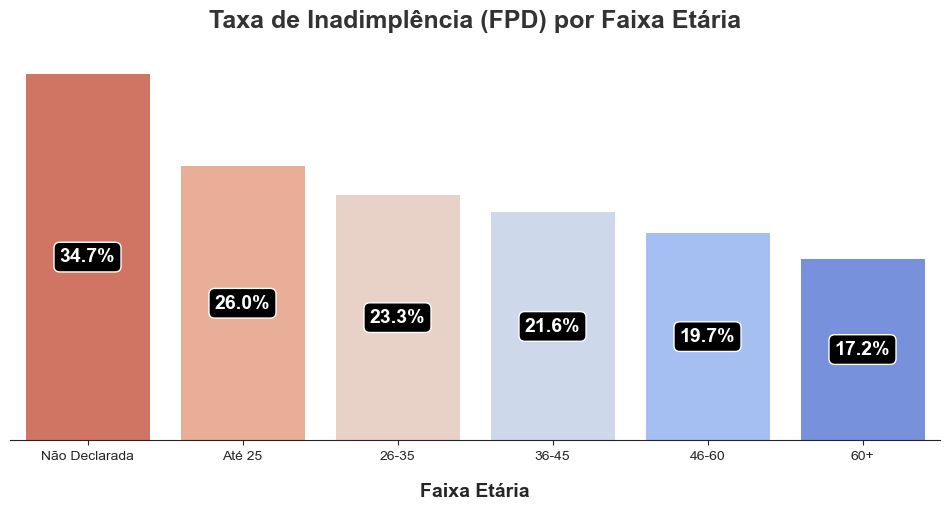

In [91]:
df['FAIXA_ETARIA'] = pd.cut(df['IDADE'], bins=[-5, 0, 25, 35, 45, 60, 100], 
                            labels=['Não Declarada', 'Até 25', '26-35', '36-45', '46-60', '60+'])

plt.figure(figsize=(12, 5))

ax = sns.barplot(
    x='FAIXA_ETARIA', 
    y=df['FPD'].astype(int), 
    data=df, 
    palette='coolwarm_r', 
    errorbar=None,
    edgecolor='none'   
)

ax.get_yaxis().set_visible(False) 
sns.despine(left=True) 

for p in ax.patches:
    height = p.get_height()
    
    if height > 0:
        ax.annotate(f'{height:.1%}', 
                    (p.get_x() + p.get_width() / 2., height / 2), 
                    ha='center', va='center', 
                    xytext=(0, 0), 
                    textcoords='offset points',
                    fontsize=14, color='white', fontweight='bold',
                    bbox=dict(boxstyle="round", fc="black"))

plt.title('Taxa de Inadimplência (FPD) por Faixa Etária', fontsize=18, pad=20, fontweight='bold', color='#333333')
plt.xlabel('Faixa Etária', fontsize=14, labelpad=15, fontweight='bold')
plt.ylabel('') 
plt.savefig('FPD por Idade', dpi=300)
plt.show()

### Análise de Portifólio

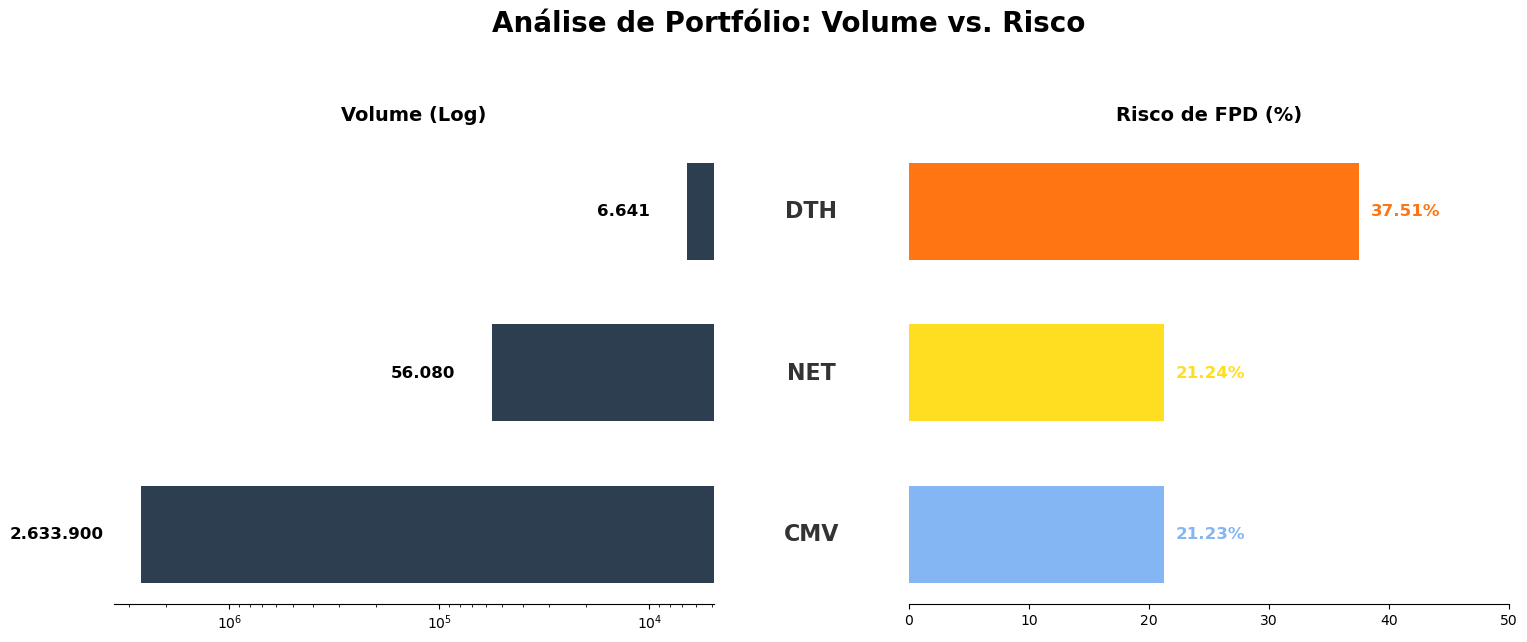

In [127]:
produtos = ['CMV', 'NET', 'DTH']
volume = [2633900, 56080, 6641]
risco = [21.23, 21.24, 37.51]

cor_vol = '#2c3e50'
cores_risco = ['#84b6f4', '#ffde21', '#ff7514']

fig, (ax1, ax_mid, ax2) = plt.subplots(1, 3, figsize=(18, 6), sharey=True, 
                                       gridspec_kw={'width_ratios': [4, 1, 4]})
plt.subplots_adjust(wspace=0.05) 

ax1.barh(produtos, volume, color=cor_vol, height=0.6)
ax1.set_xscale('log') 
ax1.invert_xaxis()    
ax1.spines['left'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_title('Volume (Log)', fontsize=14, fontweight='bold', pad=15)
ax1.get_yaxis().set_visible(False) 

for i, v in enumerate(volume):
    ax1.text(v * 1.5, i, f'{v:,}'.replace(',', '.'), va='center', ha='right', fontsize=12, fontweight='bold')

ax_mid.axis('off') 
ax_mid.set_ylim(ax1.get_ylim()) 
for i, prod in enumerate(produtos):
    ax_mid.text(0.5, i, prod, va='center', ha='center', fontsize=16, fontweight='bold', color='#333333')

ax2.barh(produtos, risco, color=cores_risco, height=0.6)
ax2.set_xlim(0, 50)
ax2.spines['left'].set_visible(False) 
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_title('Risco de FPD (%)', fontsize=14, fontweight='bold', pad=15)
ax2.get_yaxis().set_visible(False)

for i, v in enumerate(risco):
    ax2.text(v + 1, i, f'{v:.2f}%', va='center', ha='left', fontsize=12, fontweight='bold', color=cores_risco[i])

plt.suptitle('Análise de Portfólio: Volume vs. Risco', fontsize=20, fontweight='bold', y=1.10)
plt.savefig('portifolio', dpi=300)
plt.show()

## Análise do Status da Receita Federal

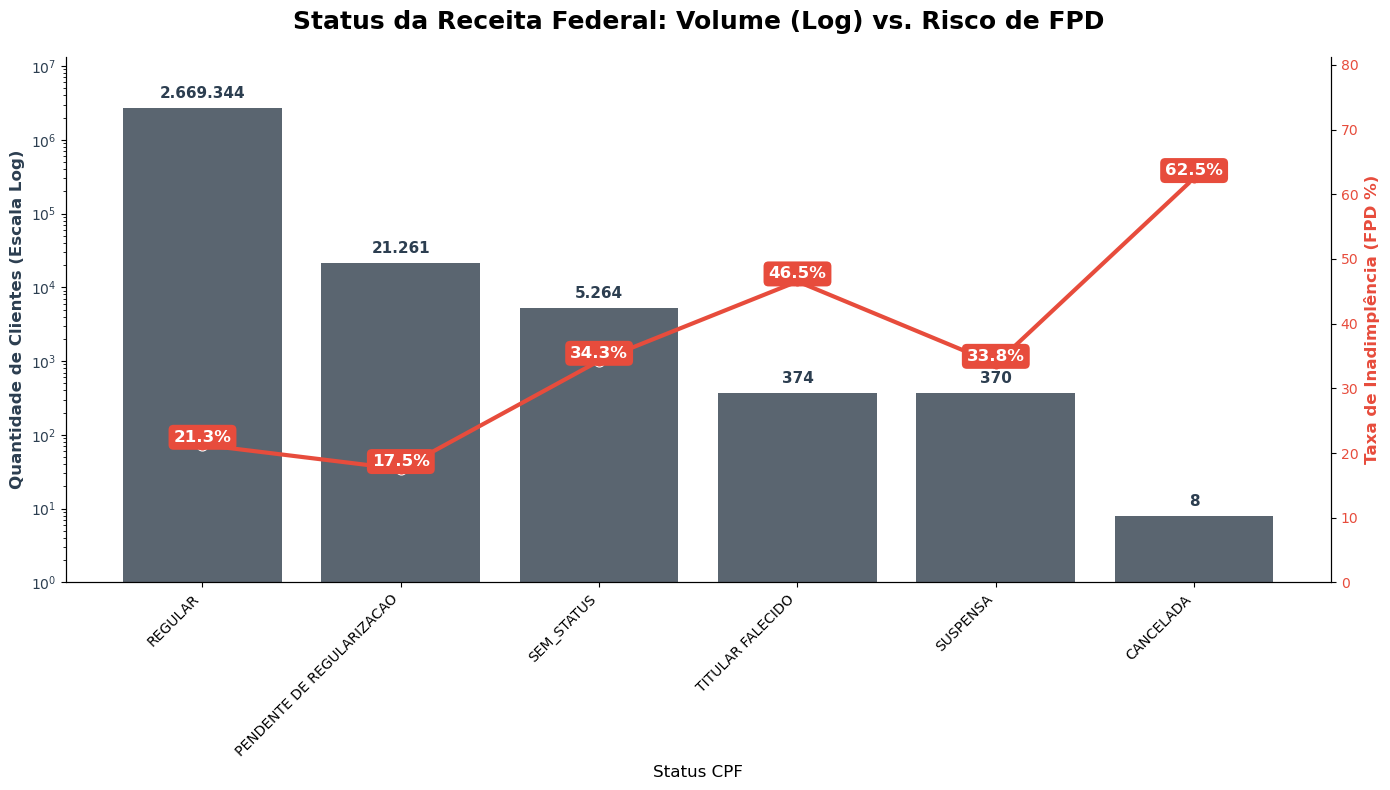

In [131]:
resumo = df.groupby('STATUSRF')['FPD'].agg(['count', 'mean']).reset_index()
resumo.columns = ['STATUSRF', 'Volume', 'FPD_Rate']

resumo = resumo.sort_values('Volume', ascending=False)
resumo['FPD_Rate'] = resumo['FPD_Rate'] * 100 

fig, ax1 = plt.subplots(figsize=(14, 8))
plt.title('Status da Receita Federal: Volume (Log) vs. Risco de FPD', fontsize=18, fontweight='bold', pad=20)

cor_barra = '#2c3e50' 
cor_linha = '#e74c3c' 

sns.barplot(data=resumo, x='STATUSRF', y='Volume', ax=ax1, color=cor_barra, alpha=0.8)

ax1.set_yscale('log') 
ax1.set_ylim(bottom=1, top=resumo['Volume'].max() * 5) 

ax1.set_ylabel('Quantidade de Clientes (Escala Log)', fontsize=12, fontweight='bold', color=cor_barra)
ax1.tick_params(axis='y', labelcolor=cor_barra)
ax1.set_xlabel('Status CPF', fontsize=12)

plt.xticks(rotation=45, ha='right')
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'{int(height):,}'.replace(',', '.'), 
                 (p.get_x() + p.get_width() / 2., height), 
                 ha='center', va='bottom', 
                 xytext=(0, 5), textcoords='offset points',
                 fontsize=11, fontweight='bold', color=cor_barra)

ax2 = ax1.twinx() 
sns.lineplot(data=resumo, x='STATUSRF', y='FPD_Rate', ax=ax2, color=cor_linha, marker='o', markersize=8, linewidth=3)

ax2.set_ylabel('Taxa de Inadimplência (FPD %)', fontsize=12, fontweight='bold', color=cor_linha)
ax2.tick_params(axis='y', labelcolor=cor_linha)
ax2.set_ylim(0, max(resumo['FPD_Rate']) * 1.3) 

for i, txt in enumerate(resumo['FPD_Rate']):
    ax2.annotate(f'{txt:.1f}%', 
                 (i, txt), 
                 ha='center', va='bottom', 
                 fontsize=12, fontweight='bold', color='white',
                 bbox=dict(boxstyle="round,pad=0.3", fc=cor_linha, ec="none"))

ax2.grid(False) 
sns.despine(right=False, left=False)
plt.tight_layout()
plt.savefig('Status_Receita', dpi=300)
plt.show()

## Análise dos Score's

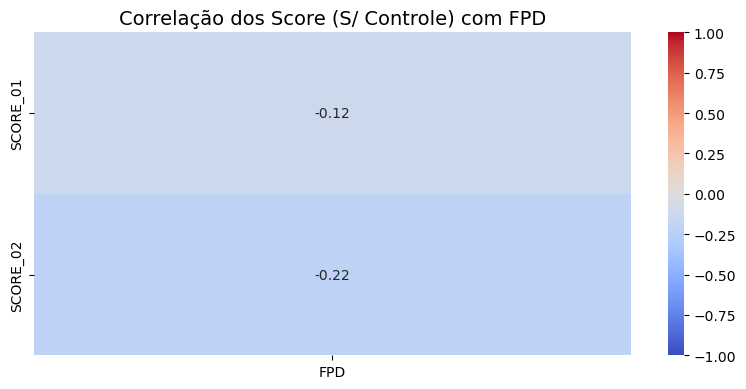

In [22]:
is_controle = df['NUM_CPF'].str[5:7].isin(['ZZ', 'ZX'])
df_s_controle = df[~is_controle].copy()


corr = df_s_controle[[
    'FPD',
    'SCORE_01',
    'SCORE_02'
]].corr()

alvo_corr = corr[['FPD']].drop('FPD').sort_values(by='FPD', ascending=False)

plt.figure(figsize=(8, 4))
sns.heatmap(alvo_corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlação dos Score (S/ Controle) com FPD', fontsize=14)
plt.tight_layout()
plt.savefig('Correlação Score', dpi=300)
plt.show()

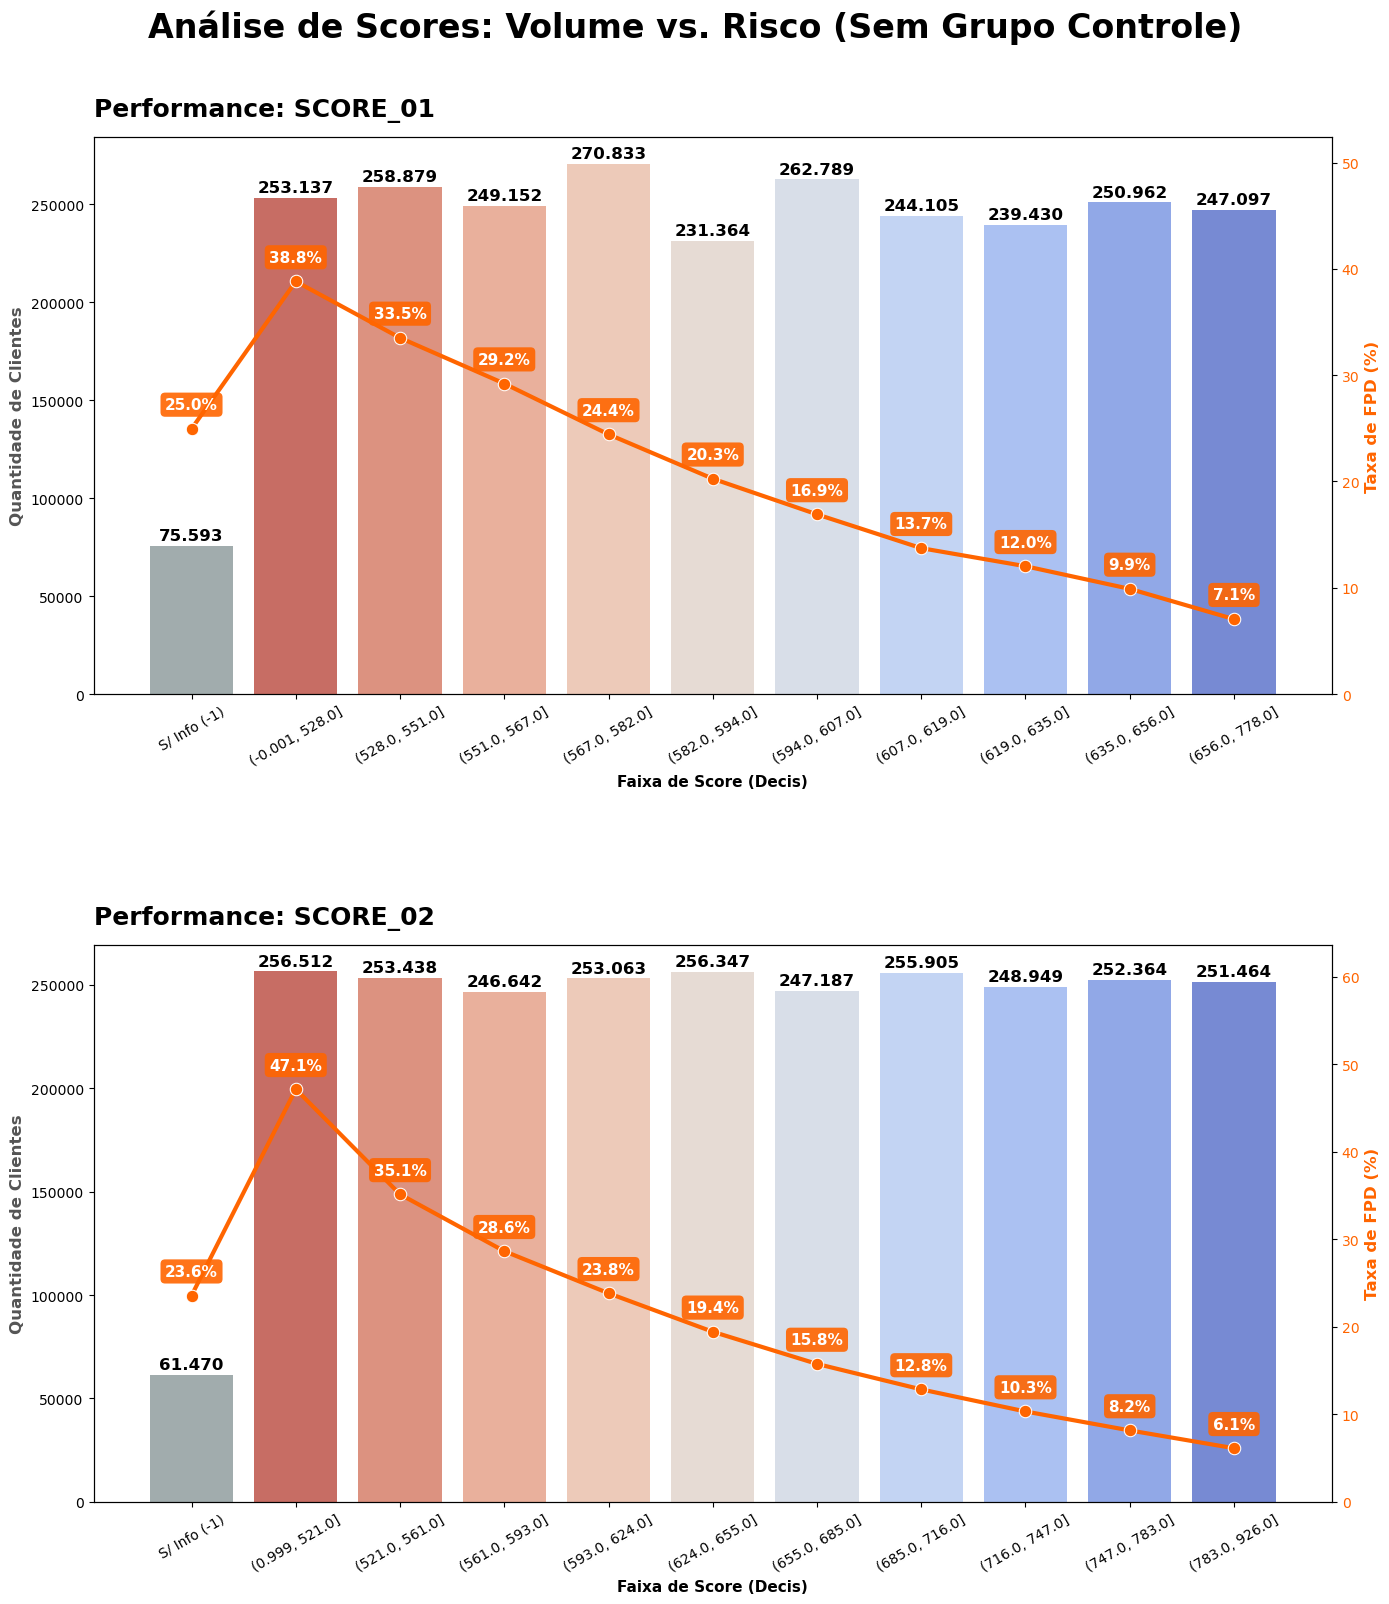

In [18]:
def prepare_data(df, score_col, sentinel_val=-1):
    df_temp = df.copy()
    mask_sentinel = df_temp[score_col] == sentinel_val
    df_temp.loc[mask_sentinel, 'FAIXA_BIN'] = f'S/ Info ({sentinel_val})'
    
    try:
        df_temp.loc[~mask_sentinel, 'FAIXA_BIN'] = pd.qcut(df_temp.loc[~mask_sentinel, score_col], q=10, duplicates='drop').astype(str)
    except:
        df_temp.loc[~mask_sentinel, 'FAIXA_BIN'] = pd.cut(df_temp.loc[~mask_sentinel, score_col], bins=5).astype(str)

    agg = df_temp.groupby('FAIXA_BIN')['FPD'].agg(['count', 'mean']).reset_index()
    agg.columns = ['Faixa', 'Volume', 'FPD_Rate']
    agg['FPD_Rate'] = agg['FPD_Rate'] * 100
    
    def sort_key(x):
        if 'S/ Info' in x: return -9999
        nums = re.findall(r"[-+]?\d*\.\d+|\d+", x)
        return float(nums[0]) if nums else 0

    agg['sort_val'] = agg['Faixa'].apply(sort_key)
    return agg.sort_values('sort_val')

is_controle = df['NUM_CPF'].str[5:7].isin(['ZZ', 'ZX'])
df_plot = df[~is_controle].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 16)) 
plt.suptitle('Análise de Scores: Volume vs. Risco (Sem Grupo Controle)', fontsize=24, fontweight='bold', y=1)

scores_to_plot = ['SCORE_01', 'SCORE_02']
line_color = '#FF6500' 

for ax1, score_col in zip(axes, scores_to_plot):
    agg_data = prepare_data(df_plot, score_col) 
    
    n_bars = len(agg_data)
    colors = sns.color_palette("coolwarm_r", n_bars - 1)
    colors.insert(0, "#95a5a6") 

    sns.barplot(data=agg_data, x='Faixa', y='Volume', ax=ax1, palette=colors, edgecolor='none', alpha=0.9)
    ax1.set_xlabel('Faixa de Score (Decis)', fontweight='bold', fontsize=11)
    ax1.set_ylabel('Quantidade de Clientes', fontweight='bold', fontsize=12, color='#555')
    ax1.tick_params(axis='x', rotation=30, labelsize=10)
    ax1.grid(False)

    for p in ax1.patches:
        height = p.get_height()
        if height > 0:
            ax1.annotate(f'{int(height):,}'.replace(',', '.'), 
                         (p.get_x() + p.get_width() / 2., height), 
                         ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', 
                         xytext=(0, 2), textcoords='offset points')

    ax2 = ax1.twinx()
    sns.lineplot(data=agg_data, x='Faixa', y='FPD_Rate', ax=ax2, color=line_color, marker='o', linewidth=3, markersize=9)
    ax2.set_ylabel('Taxa de FPD (%)', fontweight='bold', fontsize=12, color=line_color)
    ax2.tick_params(axis='y', labelcolor=line_color)
    ax2.set_ylim(0, agg_data['FPD_Rate'].max() * 1.35) 
    
    for i, txt in enumerate(agg_data['FPD_Rate']):
        ax2.annotate(f'{txt:.1f}%', (i, txt), 
                     ha='center', va='bottom', fontsize=11, fontweight='bold', color='white',
                     bbox=dict(boxstyle="round,pad=0.3", fc=line_color, ec="none", alpha=0.9),
                     xytext=(0, 12), textcoords='offset points')

    ax1.set_title(f'Performance: {score_col}', fontsize=18, fontweight='bold', loc='left', pad=15)

plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.45)
plt.savefig('Performance_Score', dpi=300)
plt.show()

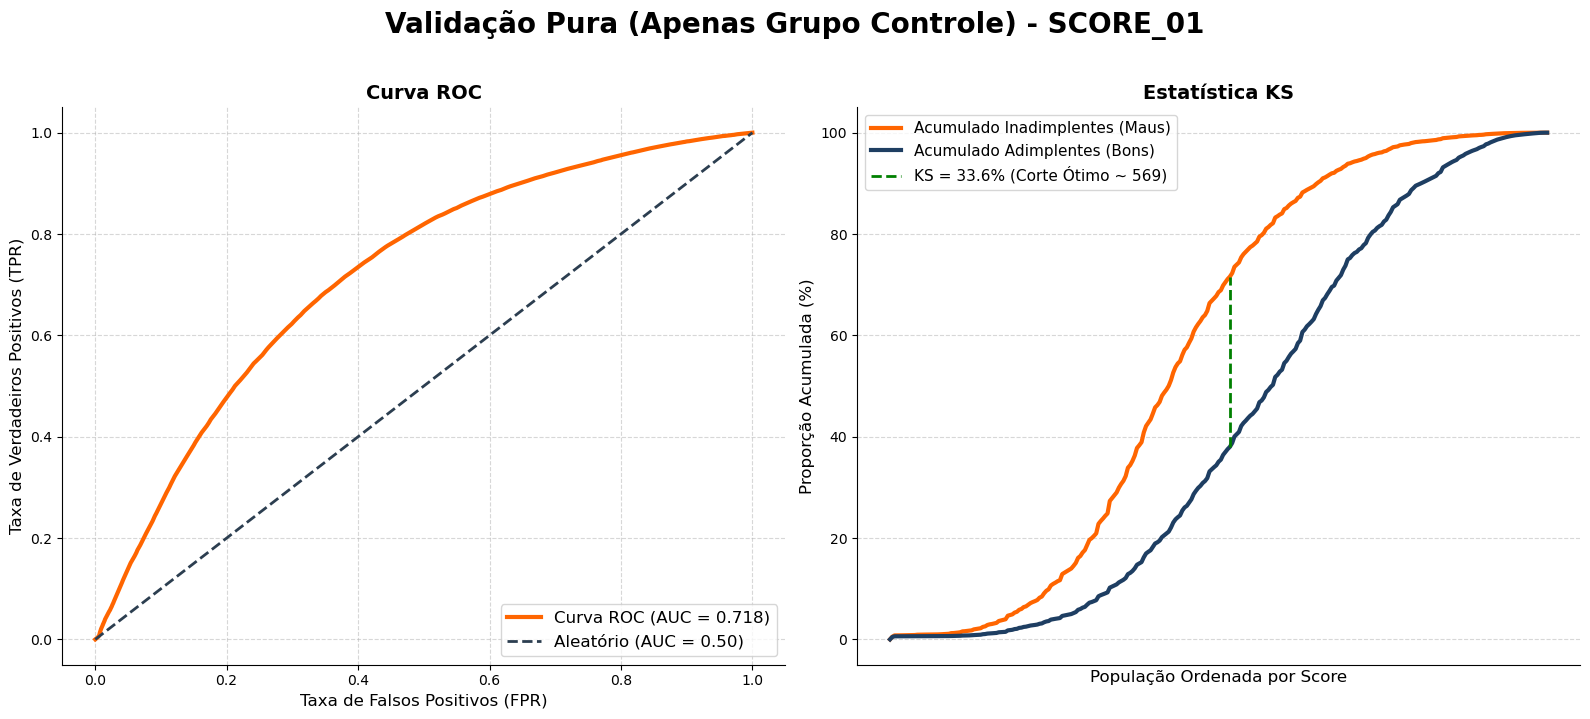

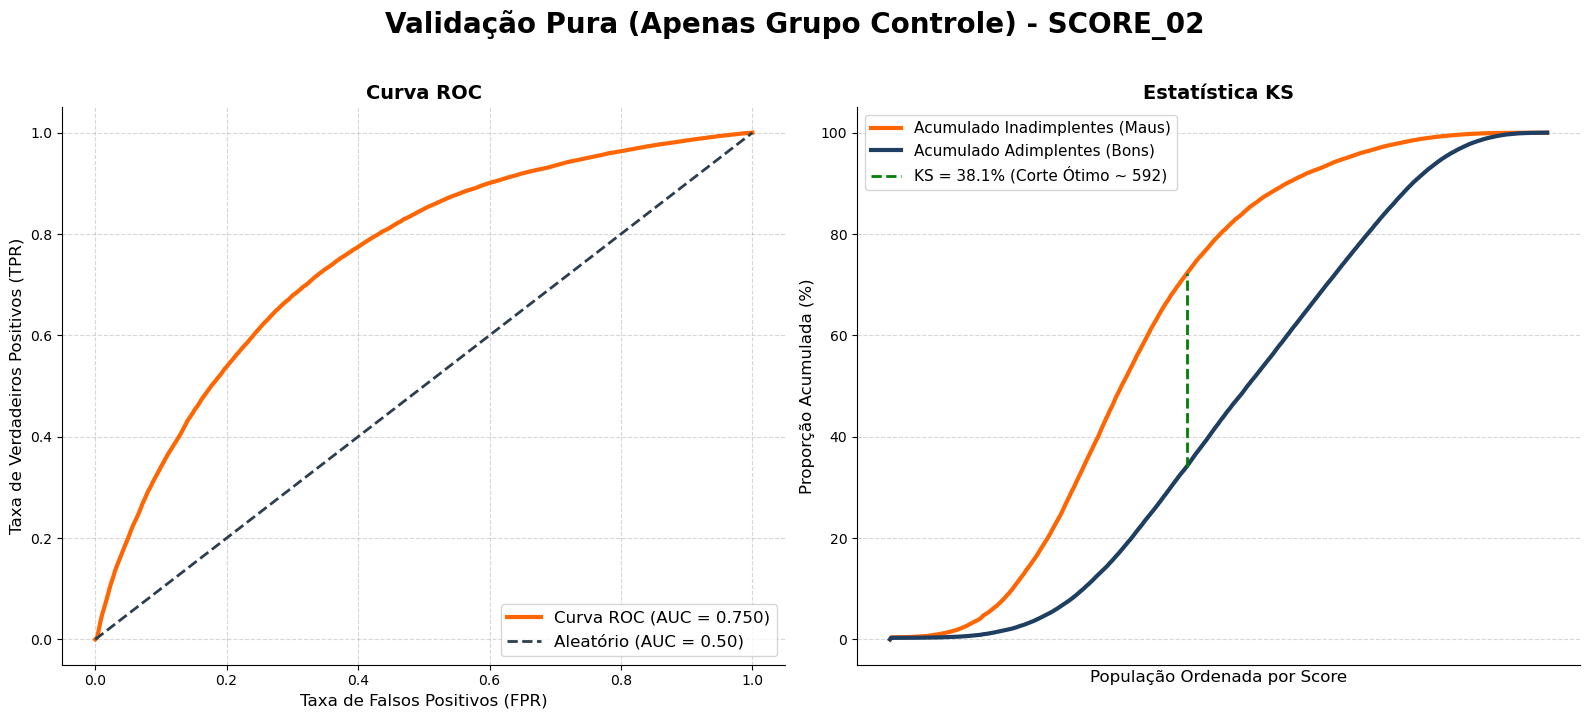

In [20]:
def plot_roc_ks_controle_cpf(df, score_col, target_col='FPD', sentinel_val=-1):

    is_controle = df['NUM_CPF'].str[5:7].isin(['ZZ', 'ZX'])

    df_controle = df[is_controle & (df[score_col] != sentinel_val)].copy()
    
    if len(df_controle) == 0:
        print(f"Aviso: Não há registros suficientes no Grupo Controle para o {score_col}.")
        return
        
    y_true = df_controle[target_col]
    y_scores = -df_controle[score_col]     

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    diferenca = tpr - fpr
    ks_stat = np.max(diferenca)
    ks_idx = np.argmax(diferenca)
    ks_score_cutoff = -thresholds[ks_idx] 

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'Validação Pura (Apenas Grupo Controle) - {score_col}', fontsize=20, fontweight='bold', y=1.02)

    ax1.plot(fpr, tpr, color='#FF6500', lw=3, label=f'Curva ROC (AUC = {roc_auc:.3f})')
    ax1.plot([0, 1], [0, 1], color='#2c3e50', lw=2, linestyle='--', label='Aleatório (AUC = 0.50)')
    ax1.set_title('Curva ROC', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
    ax1.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
    ax1.legend(loc="lower right", fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.5)

    tpr_pct, fpr_pct, ks_stat_pct = tpr * 100, fpr * 100, ks_stat * 100
    
    ax2.plot(tpr_pct, color='#FF6500', lw=3, label='Acumulado Inadimplentes (Maus)')
    ax2.plot(fpr_pct, color='#1E3E62', lw=3, label='Acumulado Adimplentes (Bons)')
    ax2.plot([ks_idx, ks_idx], [fpr_pct[ks_idx], tpr_pct[ks_idx]], 
             color='green', linestyle='--', lw=2, 
             label=f'KS = {ks_stat_pct:.1f}% (Corte Ótimo ~ {int(ks_score_cutoff)})')

    ax2.set_title('Estatística KS', fontsize=14, fontweight='bold')
    ax2.set_xlabel('População Ordenada por Score', fontsize=12)
    ax2.set_ylabel('Proporção Acumulada (%)', fontsize=12)
    ax2.legend(loc="upper left", fontsize=11)
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.set_xticks([])

    sns.despine()
    plt.tight_layout()
    plt.savefig(f'Validacap{score_col}.png', dpi=300, bbox_inches='tight')

    plt.show()

plot_roc_ks_controle_cpf(df, 'SCORE_01')
plot_roc_ks_controle_cpf(df, 'SCORE_02')

## Análise do Perfil Socioeconômico

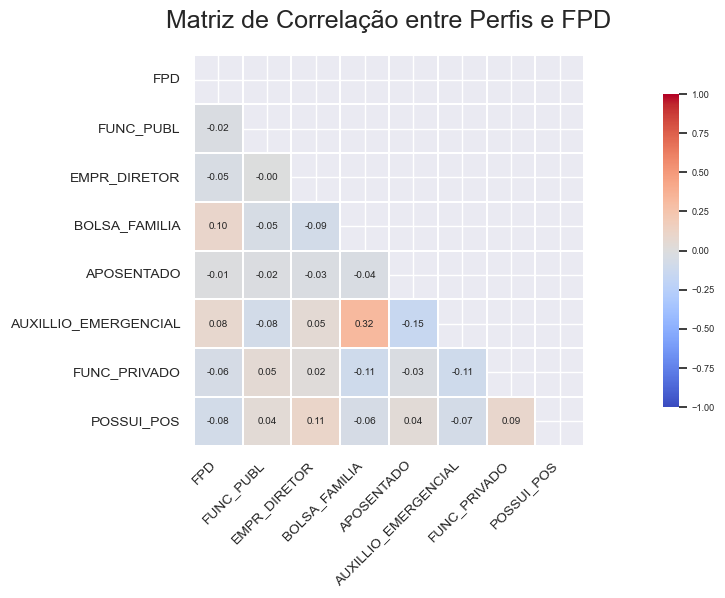

In [25]:
plt.figure(figsize=(16, 6)) 
sns.set(font_scale=0.6)

perfis = ['FPD','FUNC_PUBL', 'EMPR_DIRETOR', 'BOLSA_FAMILIA', 'APOSENTADO', 'AUXILLIO_EMERGENCIAL', 'FUNC_PRIVADO', 'POSSUI_POS']
corr = df[perfis].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

heatmap = sns.heatmap(
    corr,
    mask = mask,
    annot = True,
    fmt = '.2f',
    cmap = 'coolwarm',
    center = 0,
    vmin = -1,
    vmax = 1,
    linewidths = 0.2,
    square = True,
    cbar_kws={'shrink': 0.8}
)

plt.title('Matriz de Correlação entre Perfis e FPD', pad = 20, fontsize = 18)
plt.xticks(rotation = 45, ha = 'right', fontsize = 10)
plt.yticks(rotation = 0, fontsize = 10)

plt.tight_layout()
plt.show()

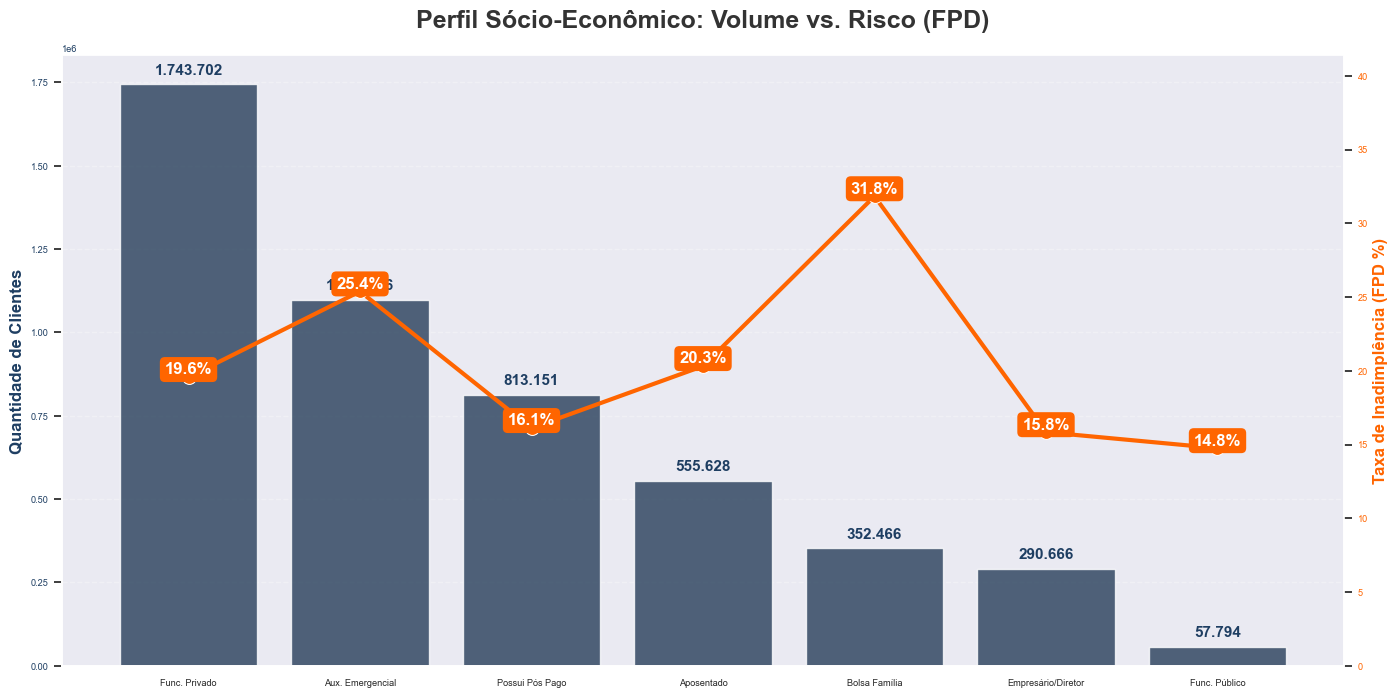

In [27]:
cols_perfil = ['FUNC_PUBL', 'EMPR_DIRETOR', 'BOLSA_FAMILIA', 'APOSENTADO', 'AUXILLIO_EMERGENCIAL', 'FUNC_PRIVADO', 'POSSUI_POS']
summary_data = []

for col in cols_perfil:
    subset = df[df[col] == 1]

    total = len(subset)
    if total > 0:
        fpd_rate = subset['FPD'].mean() * 100
    else:
        fpd_rate = 0
        
    summary_data.append({
        'Categoria': col,
        'Volume': total,
        'FPD (%)': fpd_rate
    })

df_sum = pd.DataFrame(summary_data).sort_values('Volume', ascending=False)

label_map = {
    'FUNC_PRIVADO': 'Func. Privado',
    'BOLSA_FAMILIA': 'Bolsa Família',
    'AUXILLIO_EMERGENCIAL': 'Aux. Emergencial',
    'APOSENTADO': 'Aposentado',
    'FUNC_PUBL': 'Func. Público',
    'EMPR_DIRETOR': 'Empresário/Diretor',
    'POSSUI_POS' : 'Possui Pós Pago'
}
df_sum['Categoria'] = df_sum['Categoria'].map(label_map)

fig, ax1 = plt.subplots(figsize=(14, 7))

color_bar = '#1E3E62' 
color_line = '#FF6500' 

sns.barplot(data=df_sum, x='Categoria', y='Volume', ax=ax1, color=color_bar, alpha=0.8)
ax1.set_ylabel('Quantidade de Clientes', fontsize=12, color=color_bar, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_bar)
ax1.set_xlabel('')

for i, p in enumerate(ax1.patches):
    height = p.get_height()
    ax1.annotate(f'{int(height):,}'.replace(',', '.'), 
                 (p.get_x() + p.get_width() / 2., height), 
                 ha='center', va='bottom', fontsize=11, color=color_bar, fontweight='bold',
                 xytext=(0, 5), textcoords='offset points')

ax2 = ax1.twinx() 
sns.lineplot(data=df_sum, x='Categoria', y='FPD (%)', ax=ax2, color=color_line, marker='o', markersize=10, linewidth=3)
ax2.set_ylabel('Taxa de Inadimplência (FPD %)', fontsize=12, color=color_line, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_line)
ax2.set_ylim(0, df_sum['FPD (%)'].max() * 1.3) 

for i, txt in enumerate(df_sum['FPD (%)']):
    ax2.annotate(f'{txt:.1f}%', 
                 (i, txt), 
                 ha='center', va='bottom', fontsize=12, color='white', fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.3", fc=color_line, ec="none"))

plt.title('Perfil Sócio-Econômico: Volume vs. Risco (FPD)', fontsize=18, fontweight='bold', pad=20, color='#333333')
sns.despine(ax=ax1, right=False, left=False) 
ax2.grid(False) 
ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

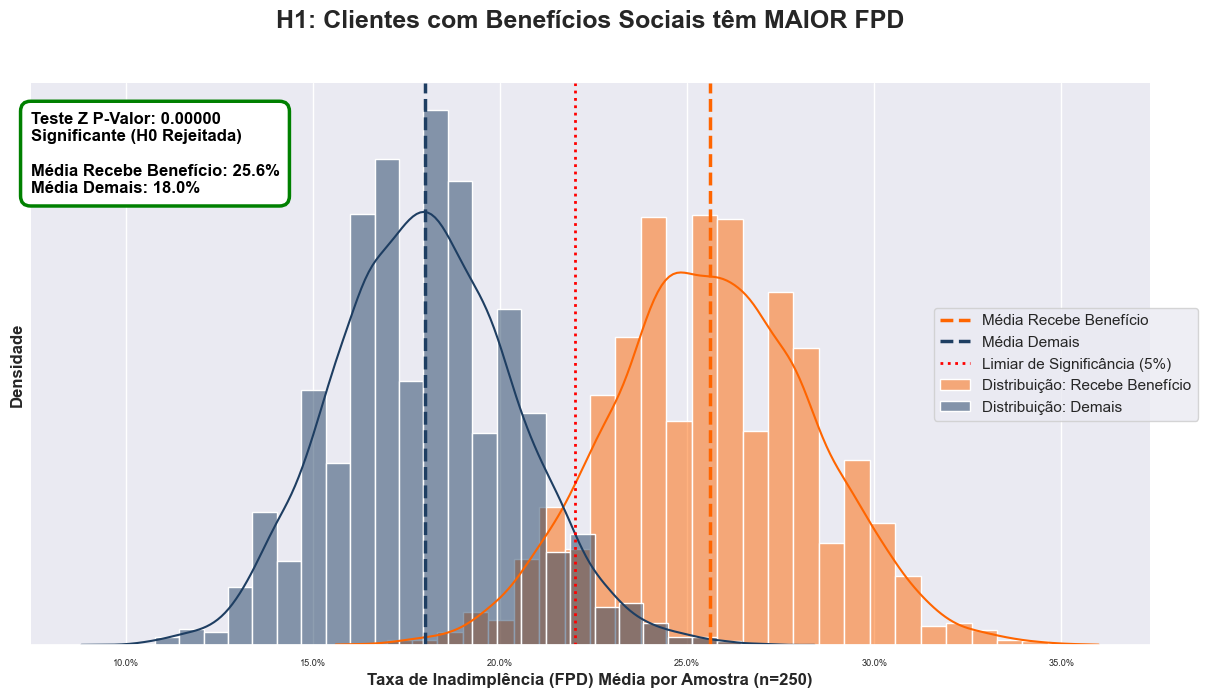

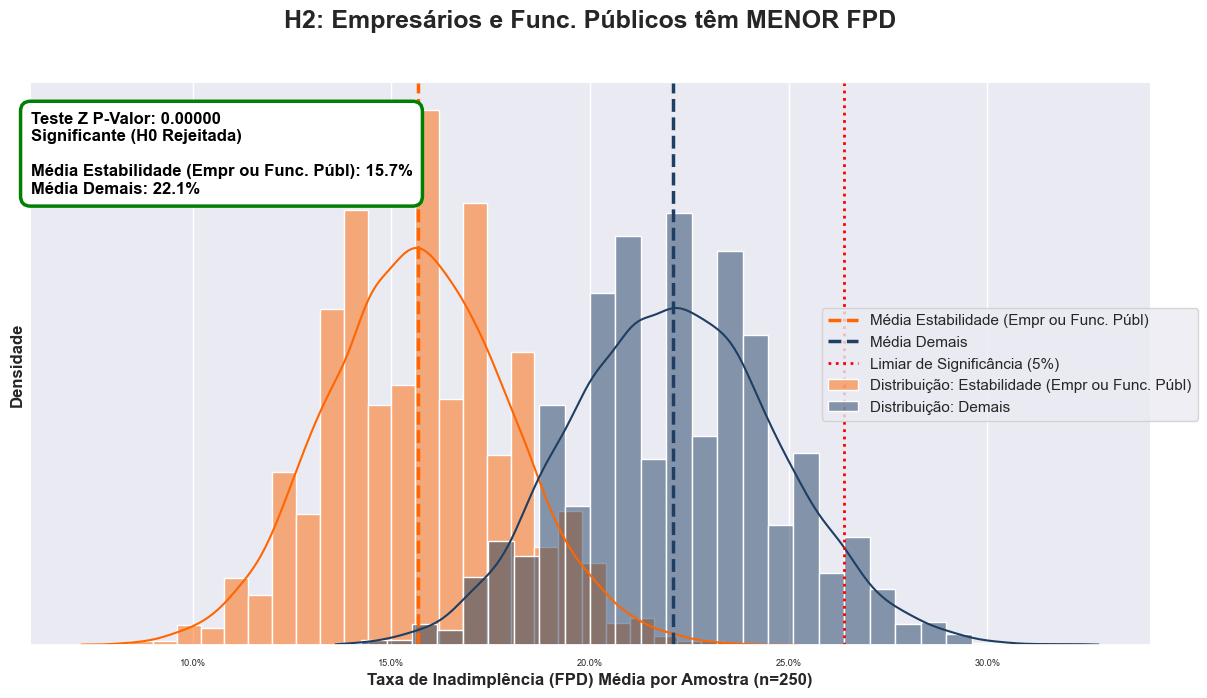

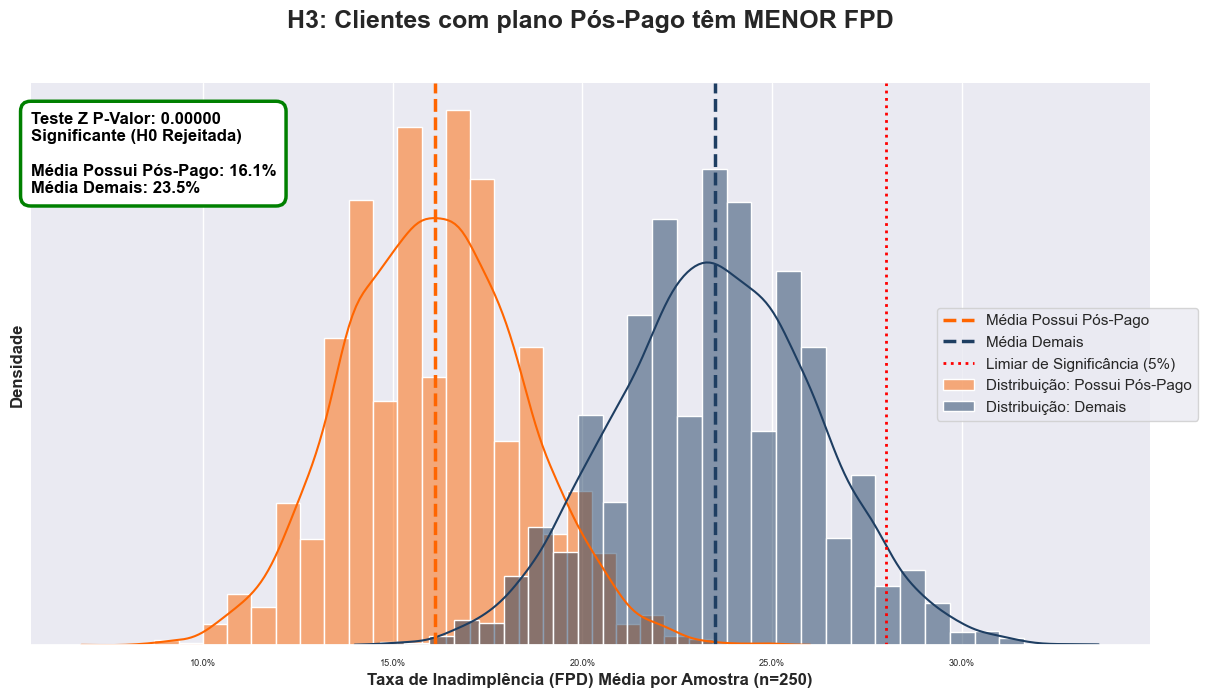

In [47]:

def plot_simulacao_oficial(df, mascara, nome_grupo, titulo):
    grupo_foco = df[mascara]['FPD'].dropna()
    grupo_resto = df[~mascara]['FPD'].dropna()
    
    p_foco = grupo_foco.mean()
    p_resto = grupo_resto.mean()    
    
    n_simulacoes = 10000
    tamanho_amostra = 250
    
    medias_foco = np.random.binomial(tamanho_amostra, p_foco, n_simulacoes) / tamanho_amostra
    medias_resto = np.random.binomial(tamanho_amostra, p_resto, n_simulacoes) / tamanho_amostra    
 
    sucessos = np.array([grupo_foco.sum(), grupo_resto.sum()])
    amostras = np.array([len(grupo_foco), len(grupo_resto)])
    z_stat, p_valor = proportions_ztest(sucessos, amostras)

    limite_significancia = np.percentile(medias_resto, 95)

    fig, ax = plt.subplots(figsize=(12, 7))

    sns.histplot(medias_foco, color='#FF6500', stat='density', kde=True, label=f'Distribuição: {nome_grupo}', alpha=0.5, bins=30, ax=ax)
    sns.histplot(medias_resto, color='#1E3E62', stat='density', kde=True, label='Distribuição: Demais', alpha=0.5, bins=30, ax=ax)

    ax.axvline(p_foco, color='#FF6500', linestyle='--', linewidth=2.5, label=f'Média {nome_grupo}')
    ax.axvline(p_resto, color='#1E3E62', linestyle='--', linewidth=2.5, label='Média Demais')
    ax.axvline(limite_significancia, color='red', linestyle=':', linewidth=2, label='Limiar de Significância (5%)')
    
    ax.set_title(titulo, fontsize=18, fontweight='bold', pad=40)
    ax.set_xlabel('Taxa de Inadimplência (FPD) Média por Amostra (n=250)', fontweight='bold', fontsize=12)
    ax.set_ylabel('Densidade', fontweight='bold', fontsize=12)

    vals = ax.get_xticks()
    ax.set_xticklabels(['{:,.1f}%'.format(x*100) for x in vals])
    ax.set_yticks([]) 
    sns.despine(left=True)

    if p_valor < 0.05:
        texto_conclusao = "Significante (H0 Rejeitada)"
        cor_borda = 'green'
    else:
        texto_conclusao = "Não Significante (Falha em rejeitar H0)"
        cor_borda = 'red'
        
    texto_caixa = (f"Teste Z P-Valor: {p_valor:.5f}\n"
                   f"{texto_conclusao}\n\n"
                   f"Média {nome_grupo}: {p_foco*100:.1f}%\n"
                   f"Média Demais: {p_resto*100:.1f}%")

    ax.text(0, 0.95, texto_caixa, transform=ax.transAxes, ha='left', va='top', 
            fontsize=12, fontweight='bold', color='black',
            bbox=dict(boxstyle='round,pad=0.6', facecolor='white', edgecolor=cor_borda, linewidth=2.5))

    ax.legend(loc='center right', bbox_to_anchor=(1.05, 0.5), fontsize=11)
    
    plt.tight_layout()
    plt.savefig(f"{nome_grupo}_Simulacao.png", dpi=300, bbox_inches='tight')
    plt.show()


mask_beneficio = (df['AUXILLIO_EMERGENCIAL'] == 1) | (df['BOLSA_FAMILIA'] == 1)
plot_simulacao_oficial(df, mask_beneficio, 'Recebe Benefício', 'H1: Clientes com Benefícios Sociais têm MAIOR FPD')

mask_estabilidade = (df['EMPR_DIRETOR'] == 1) | (df['FUNC_PUBL'] == 1)
plot_simulacao_oficial(df, mask_estabilidade, 'Estabilidade (Empr ou Func. Públ)', 'H2: Empresários e Func. Públicos têm MENOR FPD')

mask_pos = (df['POSSUI_POS'] == 1)
plot_simulacao_oficial(df, mask_pos, 'Possui Pós-Pago', 'H3: Clientes com plano Pós-Pago têm MENOR FPD')